In [22]:
import math
from pathlib import Path
from typing import Dict, List, Tuple

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from scipy.signal import find_peaks
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix, classification_report

# 경로 설정
BASE_DIR = Path('/home/binghin2/Myproject')
MODEL_CANDIDATES = [
    BASE_DIR / 'Research' / 'CATSA' / 'Train' / 'Individual_data' / 'ALL' / 'Save_model' / 'ALL_Grand_Final_Production_Model.pt',
]
MODEL_PATH = next((p for p in MODEL_CANDIDATES if p.exists()), MODEL_CANDIDATES[0])
DATA_ROOT = BASE_DIR / 'Dataset' / 'EmpaticaE4Stress' / 'Subjects'

SUBJECTS = [f'subject_{i:02d}' for i in range(1, 7)]
FS_ACC = 32
FS_SLOW = 4

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')
print(f'Model exists: {MODEL_PATH.exists()} -> {MODEL_PATH}')
print(f'Using fixed subjects: {SUBJECTS}')

Device: cuda
Model exists: True -> /home/binghin2/Myproject/Research/CATSA/Train/Individual_data/ALL/Save_model/ALL_Grand_Final_Production_Model.pt
Using fixed subjects: ['subject_01', 'subject_02', 'subject_03', 'subject_04', 'subject_05', 'subject_06']


In [23]:
# ==========================================
# 1. Model Definition (CATSA 학습 아키텍처와 동일)
# ==========================================
import re


class PositionalEncoding(nn.Module):
    def __init__(self, d_model: int, max_len: int = 1024, dropout: float = 0.1):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        pe = torch.zeros(max_len, d_model)
        pos = torch.arange(0, max_len, dtype=torch.float32).unsqueeze(1)
        div = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x):
        return self.dropout(x + self.pe[:, :x.size(1)])


class MultiModal1DCNNTransformer(nn.Module):
    def __init__(self, hp: Dict):
        super().__init__()
        d_model = int(hp.get('transformer_d_model', 48))
        dropout = float(hp.get('dropout_rate', 0.4))

        self.acc_branch = nn.Sequential(
            nn.Conv1d(3, 16, 9, stride=4, padding=4), nn.BatchNorm1d(16), nn.GELU(), nn.Dropout(dropout),
            nn.Conv1d(16, 32, 9, stride=2, padding=4), nn.BatchNorm1d(32), nn.GELU(), nn.Dropout(dropout)
        )
        self.slow_branch = nn.Sequential(
            nn.Conv1d(4, 16, 5, padding=2), nn.BatchNorm1d(16), nn.GELU(), nn.Dropout(dropout),
            nn.Conv1d(16, 16, 3, padding=1), nn.BatchNorm1d(16), nn.GELU(), nn.Dropout(dropout)
        )
        self.posenc = PositionalEncoding(d_model, dropout=dropout)
        enc_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=int(hp.get('transformer_heads', 8)),
            dim_feedforward=int(hp.get('transformer_ff_dim', 192)),
            dropout=dropout, batch_first=True, norm_first=True, activation='gelu'
        )
        self.transformer = nn.TransformerEncoder(enc_layer, num_layers=int(hp.get('transformer_layers', 2)), enable_nested_tensor=False)
        self.norm = nn.LayerNorm(d_model)
        self.cls = nn.Linear(d_model, 2)

    def forward(self, acc, slow):
        fused = torch.cat([self.acc_branch(acc), self.slow_branch(slow)], dim=1)
        x = self.posenc(fused.permute(0, 2, 1).contiguous())
        return self.cls(self.norm(self.transformer(x)).mean(dim=1))


# ==========================================
# 2. Data Processing Functions
# ==========================================
def _parse_numeric_token(token: str) -> float:
    s = str(token).strip().replace('\ufeff', '')
    if s == '' or s.lower() in {'nan', 'none'}:
        return float('nan')
    s = s.replace(' ', '')

    # '1.038.145' 같은 비정상 표기를 마지막 구분자만 소수점으로 보고 보정한다.
    last_dot = s.rfind('.')
    last_comma = s.rfind(',')
    if last_dot != -1 or last_comma != -1:
        dec_pos = max(last_dot, last_comma)
        int_part = re.sub(r'[.,]', '', s[:dec_pos])
        frac_part = re.sub(r'[.,]', '', s[dec_pos + 1:])
        s = int_part if frac_part == '' else f'{int_part}.{frac_part}'

    try:
        return float(s)
    except ValueError:
        return float('nan')


def _fill_nan_1d(arr: np.ndarray) -> np.ndarray:
    if arr.size == 0:
        return arr.astype(np.float32)

    series = pd.Series(arr, dtype='float64')
    if series.notna().sum() == 0:
        return np.zeros(arr.shape[0], dtype=np.float32)

    return (
        series.interpolate(limit_direction='both')
        .bfill()
        .ffill()
        .to_numpy(dtype=np.float32)
    )


def _read_empatica_signal(path: Path, n_cols: int) -> np.ndarray:
    raw = pd.read_csv(path, header=None, dtype=str)
    values_df = raw.iloc[:, :n_cols].apply(lambda col: col.map(_parse_numeric_token))
    values = values_df.to_numpy(dtype=np.float32).copy()

    # Empatica 원본 CSV의 첫 2행(timestamp, sample rate)을 제거한다.
    if values.shape[0] > 2:
        values = values[2:].copy()

    if n_cols == 1:
        return _fill_nan_1d(values[:, 0])

    for col in range(values.shape[1]):
        values[:, col] = _fill_nan_1d(values[:, col])
    return values


def bvp_to_hr_hrv_4hz(bvp_64: np.ndarray, fs: int = 64, out_fs: int = 4):
    sig = np.asarray(bvp_64, dtype=np.float32).reshape(-1)
    peaks, _ = find_peaks(sig, distance=int(fs * 0.30))
    n4 = len(sig) // (fs // out_fs)
    t4 = np.arange(n4) / float(out_fs)
    if len(peaks) < 3:
        return np.zeros(n4, dtype=np.float32), np.zeros(n4, dtype=np.float32)
    t_peaks = peaks / float(fs)
    ibi = np.clip(np.diff(t_peaks), 1e-3, None)
    hr_4 = np.interp(t4, t_peaks[1:], 60.0 / ibi).astype(np.float32)
    hrv = pd.Series(ibi).rolling(window=10, min_periods=1).std().fillna(0).values
    hrv_4 = np.interp(t4, t_peaks[1:], hrv).astype(np.float32)
    return hr_4, hrv_4


def load_multimodal_csv(path: Path) -> Tuple[np.ndarray, np.ndarray]:
    acc = _read_empatica_signal(path / 'ACC.csv', n_cols=3)
    bvp = _read_empatica_signal(path / 'BVP.csv', n_cols=1)
    eda = _read_empatica_signal(path / 'EDA.csv', n_cols=1)
    temp = _read_empatica_signal(path / 'TEMP.csv', n_cols=1)

    hr_4, hrv_4 = bvp_to_hr_hrv_4hz(bvp)

    t4 = min(len(eda), len(temp), len(hr_4), len(hrv_4), len(acc) // 8)

    eda = eda[:t4]
    temp = temp[:t4]
    hr_4 = hr_4[:t4]
    hrv_4 = hrv_4[:t4]
    acc = acc[:t4 * 8]

    slow = np.stack([eda, temp, hr_4, hrv_4], axis=1).astype(np.float32)
    return acc, slow


def build_protocol_labels_4hz(total_len_4hz: int, fs: int = 4) -> Tuple[np.ndarray, int]:
    fixed_sec = {
        'rest0': 3 * 60, 'task1': 10 * 60, 'rest1': 2 * 60, 'task2': 5 * 60,
        'rest2': 2 * 60, 'task3': 3 * 60, 'rest3': 2 * 60, 'rest4': 2 * 60,
        'task5': 1 * 60, 'rest5': 2 * 60,
    }
    fixed = {k: int(v * fs) for k, v in fixed_sec.items()}
    fixed_total = sum(fixed.values())
    task4 = total_len_4hz - fixed_total

    labels = np.full((total_len_4hz,), -1, dtype=np.int64)
    segments = [
        ('rest0', fixed['rest0'], 0), ('task1', fixed['task1'], 1), ('rest1', fixed['rest1'], -1),
        ('task2', fixed['task2'], 1), ('rest2', fixed['rest2'], -1), ('task3', fixed['task3'], 1),
        ('rest3', fixed['rest3'], -1), ('task4', task4, 1), ('rest4', fixed['rest4'], -1),
        ('task5', fixed['task5'], 1), ('rest5', fixed['rest5'], -1),
    ]

    cur = 0
    for name, dur, lab in segments:
        end = min(cur + dur, total_len_4hz)
        if end > cur:
            labels[cur:end] = lab
        cur = end
        if cur >= total_len_4hz:
            break

    return labels, int(task4 / fs)


def normalize_multimodal(acc: np.ndarray, slow: np.ndarray, labels_4hz: np.ndarray):
    use_mask_4hz = labels_4hz >= 0
    if not np.any(use_mask_4hz):
        use_mask_4hz = np.ones(len(labels_4hz), dtype=bool)

    slow_mu = np.mean(slow[use_mask_4hz], axis=0)
    slow_sigma = np.std(slow[use_mask_4hz], axis=0) + 1e-8
    slow_norm = (slow - slow_mu) / slow_sigma

    use_mask_32hz = np.repeat(use_mask_4hz, 8)
    acc_mu = np.mean(acc[use_mask_32hz], axis=0)
    acc_sigma = np.std(acc[use_mask_32hz], axis=0) + 1e-8
    acc_norm = (acc - acc_mu) / acc_sigma

    return acc_norm.astype(np.float32), slow_norm.astype(np.float32)


def sliding_windows_multimodal(acc, slow, labels_4hz, win_sec=60, stride_sec=10):
    x_acc, x_slow, y_out = [], [], []
    win_4hz = win_sec * FS_SLOW
    stride_4hz = stride_sec * FS_SLOW

    for i in range(0, len(labels_4hz) - win_4hz + 1, stride_4hz):
        w_lab = labels_4hz[i:i + win_4hz]
        uniq = np.unique(w_lab)
        if len(uniq) == 1 and uniq[0] in (0, 1):
            x_slow.append(slow[i: i + win_4hz].T.copy())
            x_acc.append(acc[i * 8: (i + win_4hz) * 8].T.copy())
            y_out.append(int(uniq[0]))

    if not x_acc:
        return np.empty((0, 3, win_sec * FS_ACC)), np.empty((0, 4, win_sec * FS_SLOW)), np.empty((0,))
    return np.asarray(x_acc), np.asarray(x_slow), np.asarray(y_out, dtype=np.int64)

In [24]:
# 체크포인트 로드
ckpt = torch.load(MODEL_PATH, map_location=DEVICE)

if isinstance(ckpt, dict) and 'model_state_dict' in ckpt:
    model_state = ckpt['model_state_dict']
    hp = ckpt.get('hyperparameters', {})
else:
    model_state = ckpt
    hp = {}

hp.setdefault('window_seconds', 60)
hp.setdefault('stride_seconds', 10)
hp.setdefault('transformer_d_model', 48)
hp.setdefault('transformer_heads', 8)
hp.setdefault('transformer_ff_dim', 192)
hp.setdefault('transformer_dropout', 0.4)
hp.setdefault('transformer_layers', 2)

WIN_SEC = int(hp['window_seconds'])
STRIDE_SEC = int(hp['stride_seconds'])

model = MultiModal1DCNNTransformer(hp).to(DEVICE)
model.load_state_dict(model_state)
model.eval()

print('Loaded ALL Modality model checkpoint successfully')
print(f'window_sec={WIN_SEC}, stride_sec={STRIDE_SEC}, ACC={FS_ACC}Hz, SLOW={FS_SLOW}Hz')

Loaded ALL Modality model checkpoint successfully
window_sec=60, stride_sec=10, ACC=32Hz, SLOW=4Hz


In [25]:
# subject_01 ~ subject_06 추론 및 평가
rows = []
all_true: List[int] = []
all_pred: List[int] = []

with torch.no_grad():
    for sub in SUBJECTS:
        sub_path = DATA_ROOT / sub
        try:
            acc, slow = load_multimodal_csv(sub_path)
        except Exception as e:
            print(f"Skipping {sub} due to load error: {e}")
            continue

        labels_4hz, task4_sec = build_protocol_labels_4hz(total_len_4hz=len(slow), fs=FS_SLOW)
        acc_norm, slow_norm = normalize_multimodal(acc, slow, labels_4hz)

        x_acc, x_slow, y_true = sliding_windows_multimodal(
            acc_norm,
            slow_norm,
            labels_4hz,
            win_sec=WIN_SEC,
            stride_sec=STRIDE_SEC,
        )

        if len(y_true) == 0:
            rows.append({
                'subject': sub,
                'n_samples_4hz': len(slow),
                'task4_sec': task4_sec,
                'n_eval_windows': 0,
                'accuracy': np.nan,
                'f1': np.nan,
                'precision': np.nan,
                'recall': np.nan,
                'note': 'No valid windows after masking',
            })
            continue

        t_acc = torch.from_numpy(x_acc).to(DEVICE)
        t_slow = torch.from_numpy(x_slow).to(DEVICE)

        logits = model(t_acc, t_slow)  # ALL 모델은 (B, 2) 크기의 logits 반환
        y_pred = logits.argmax(dim=1).cpu().numpy()

        acc_score = accuracy_score(y_true, y_pred)
        f1 = f1_score(y_true, y_pred, zero_division=0)
        prec = precision_score(y_true, y_pred, zero_division=0)
        rec = recall_score(y_true, y_pred, zero_division=0)

        rows.append({
            'subject': sub,
            'n_samples_4hz': len(slow),
            'task4_sec': task4_sec,
            'n_eval_windows': int(len(y_true)),
            'accuracy': float(acc_score),
            'f1': float(f1),
            'precision': float(prec),
            'recall': float(rec),
        })

        all_true.extend(y_true.tolist())
        all_pred.extend(y_pred.tolist())

result_df = pd.DataFrame(rows)
print('=== Per-subject metrics ===')
display(result_df)

if len(all_true) > 0:
    overall_acc = accuracy_score(all_true, all_pred)
    overall_f1 = f1_score(all_true, all_pred, zero_division=0)
    overall_prec = precision_score(all_true, all_pred, zero_division=0)
    overall_rec = recall_score(all_true, all_pred, zero_division=0)

    print('\n=== Overall metrics (subject_01~06) ===')
    print(f'Accuracy : {overall_acc:.4f}')
    print(f'F1       : {overall_f1:.4f}')
    print(f'Precision: {overall_prec:.4f}')
    print(f'Recall   : {overall_rec:.4f}')

    cm = confusion_matrix(all_true, all_pred)
    print('\nConfusion Matrix [rows=true, cols=pred]')
    print(cm)

    print('\nClassification Report')
    print(classification_report(all_true, all_pred, target_names=['Non-stress', 'Stress'], zero_division=0))
else:
    print('No aggregated samples to evaluate.')

=== Per-subject metrics ===


,subject,n_samples_4hz,task4_sec,n_eval_windows,accuracy,f1,precision,recall
0,subject_01,10014,583,159,0.238994,0.338798,0.837838,0.212329
1,subject_02,9418,434,144,0.020833,0.000000,0.000000,0.000000
2,subject_03,8302,155,116,0.155172,0.092593,1.000000,0.048544
3,subject_04,8432,188,119,0.218487,0.218487,1.000000,0.122642
4,subject_05,8332,163,117,0.085470,0.100840,0.400000,0.057692
5,subject_06,8650,242,125,0.120000,0.214286,0.535714,0.133929



=== Overall metrics (subject_01~06) ===
Accuracy : 0.1410
F1       : 0.1728
Precision: 0.6481
Recall   : 0.0997

Confusion Matrix [rows=true, cols=pred]
[[ 40  38]
 [632  70]]

Classification Report
              precision    recall  f1-score   support

  Non-stress       0.06      0.51      0.11        78
      Stress       0.65      0.10      0.17       702

    accuracy                           0.14       780
   macro avg       0.35      0.31      0.14       780
weighted avg       0.59      0.14      0.17       780



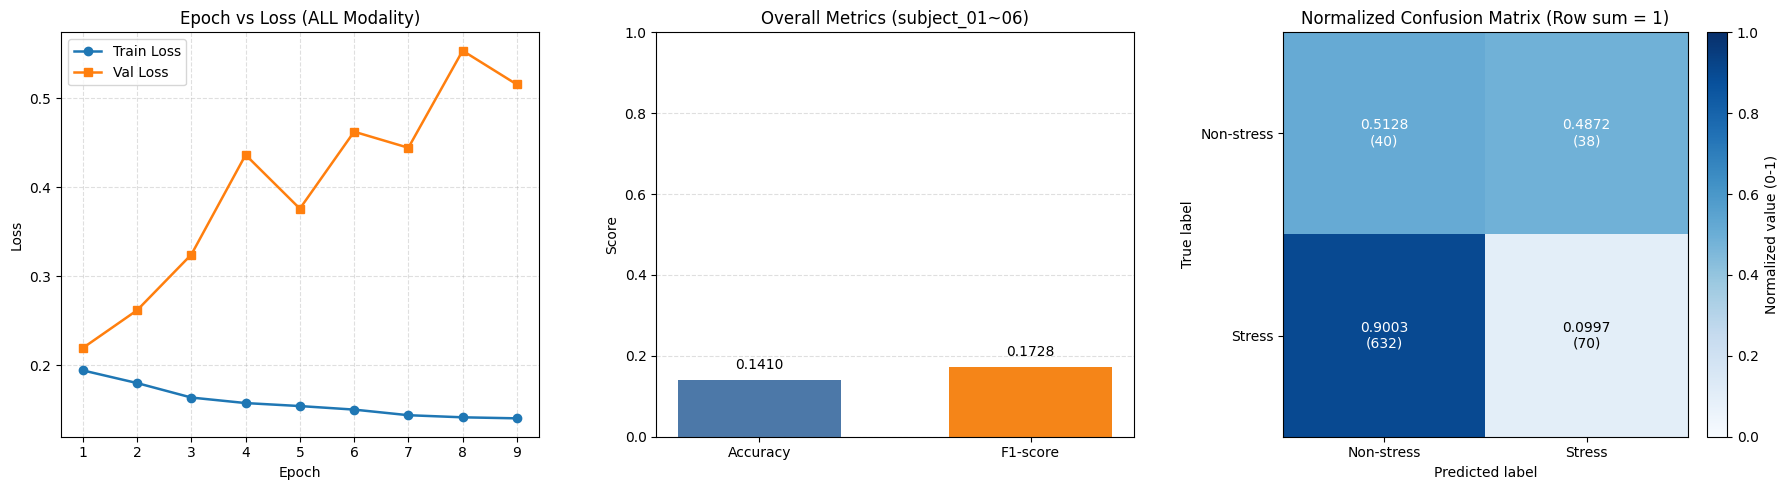

In [26]:
import matplotlib.pyplot as plt

if len(all_true) == 0:
    raise RuntimeError('No aggregated samples to visualize.')

accuracy = accuracy_score(all_true, all_pred)
f1_val = f1_score(all_true, all_pred, zero_division=0)
cm = confusion_matrix(all_true, all_pred)
class_names = ['Non-stress', 'Stress']

cm_norm = cm.astype(float) / np.maximum(cm.sum(axis=1, keepdims=True), 1)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1) Epoch / Loss graph (checkpoint history 사용)
history = ckpt.get('history', []) if isinstance(ckpt, dict) else []
if history:
    epochs = [int(h.get('epoch', i + 1)) for i, h in enumerate(history)]
    train_loss = [float(h.get('train_loss', np.nan)) for h in history]
    val_loss = [float(h.get('val_loss', np.nan)) for h in history]

    axes[0].plot(epochs, train_loss, marker='o', linewidth=1.8, label='Train Loss')
    axes[0].plot(epochs, val_loss, marker='s', linewidth=1.8, label='Val Loss')
    axes[0].set_title('Epoch vs Loss (ALL Modality)')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].grid(True, linestyle='--', alpha=0.4)
    axes[0].legend()
else:
    axes[0].text(0.5, 0.5, 'No history in checkpoint', ha='center', va='center', fontsize=11)
    axes[0].set_title('Epoch vs Loss')
    axes[0].set_xticks([])
    axes[0].set_yticks([])

# 2) F1-score / Accuracy bar graph
metrics = ['Accuracy', 'F1-score']
values = [accuracy, f1_val]
colors = ['#4C78A8', '#F58518']

bars = axes[1].bar(metrics, values, color=colors, width=0.6)
axes[1].set_ylim(0, 1)
axes[1].set_title('Overall Metrics (subject_01~06)')
axes[1].set_ylabel('Score')
axes[1].grid(axis='y', linestyle='--', alpha=0.4)

for bar, v in zip(bars, values):
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        v + 0.02,
        f'{v:.4f}',
        ha='center',
        va='bottom',
        fontsize=10,
    )

# 3) Confusion matrix
im = axes[2].imshow(cm_norm, interpolation='nearest', cmap='Blues', vmin=0, vmax=1)
axes[2].set_title('Normalized Confusion Matrix (Row sum = 1)')
axes[2].set_xlabel('Predicted label')
axes[2].set_ylabel('True label')
axes[2].set_xticks(np.arange(len(class_names)))
axes[2].set_yticks(np.arange(len(class_names)))
axes[2].set_xticklabels(class_names)
axes[2].set_yticklabels(class_names)

threshold = cm_norm.max() / 2 if cm_norm.size else 0.5
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        axes[2].text(
            j,
            i,
            f'{cm_norm[i, j]:.4f}\n({cm[i, j]})',
            ha='center',
            va='center',
            color='white' if cm_norm[i, j] > threshold else 'black',
            fontsize=10,
        )

cbar = fig.colorbar(im, ax=axes[2], fraction=0.046, pad=0.04)
cbar.set_label('Normalized value (0-1)')

plt.tight_layout()
plt.show()